<a href="https://www.kaggle.com/code/ranajahanvi/streaming-platform-analysis?scriptVersionId=322989651" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# =============================================================================

# OTT: Streaming Service Analytics & Business Intelligence Engine

# =============================================================================

#

# PROJECT OVERVIEW

# -----------------------------------------------------------------------------

# This project performs an end-to-end analytical assessment of a streaming

# service platform using Python-based data analysis techniques. The objective is

# to transform raw user activity, subscription, engagement, and content

# consumption data into meaningful business insights through statistical

# analysis, KPI engineering, trend identification, and data visualization.

#

# The analysis focuses on understanding customer behavior, content performance,

# platform growth, subscription revenue dynamics, and engagement patterns to

# support data-driven decision making.

#

# =============================================================================

# CORE ANALYTICAL WORKFLOWS

# =============================================================================

#

# 1. CONTENT PERFORMANCE ANALYSIS

# • Identifies the most popular content genres.

# • Measures average watch hours across genres.

# • Evaluates content engagement levels to support content strategy.

#

# 2. MEMBERSHIP & REVENUE ANALYSIS

# • Analyzes membership distribution across subscription tiers.

# • Calculates revenue contribution by membership category.

# • Evaluates subscription pricing patterns across payment methods.

#

# 3. USER ENGAGEMENT ANALYSIS

# • Measures platform watch-hour consumption.

# • Computes engagement efficiency metrics.

# • Assesses user activity and viewing behavior patterns.

#

# 4. CUSTOMER SATISFACTION ANALYSIS

# • Examines user rating behavior.

# • Performs correlation analysis between watch hours and ratings.

# • Identifies relationships between engagement and satisfaction.

#

# 5. GROWTH & ACQUISITION ANALYSIS

# • Processes temporal user registration data.

# • Tracks monthly acquisition trends.

# • Calculates growth rates and peak acquisition periods.

#

# 6. KPI ENGINEERING & EXECUTIVE REPORTING

# • Generates platform health indicators.

# • Calculates engagement benchmarks.

# • Produces revenue and growth performance metrics.

# • Summarizes actionable business insights.

#

# 7. DATA VISUALIZATION

# • Genre engagement analysis using bar charts.

# • User behavior distribution using histograms.

# • Monthly acquisition trend analysis using line charts.

# • Executive-level analytical reporting through visual storytelling.

#

# =============================================================================

# TECHNOLOGIES & LIBRARIES USED

# =============================================================================

#

# • Python

# • Pandas

# • NumPy

# • Matplotlib

# • Statistical Analysis

# • Exploratory Data Analysis (EDA)

# • Correlation Analysis

# • Time-Series Analysis

# • KPI Engineering

# • Business Intelligence Analytics

#

# =============================================================================

# PROJECT OUTCOME

# =============================================================================

#

# Developed a comprehensive analytics engine capable of extracting strategic

# business insights from streaming platform data through data preprocessing,

# statistical evaluation, KPI generation, trend analysis, and professional

# visualization techniques.

#

# =============================================================================


In [2]:
# Standard libraries used in real-world analytics.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [3]:
#Understanding structure & first look at data


df = pd.read_csv("/kaggle/input/datasets/ranajahanvi/streaming-platform-data/streaming_service_data.csv") 
# his uses the Pandas library to read the CSV file and store it in a structured format called a DataFrame (df).

df.head()
# This function returns the first five observations of the dataset.

,User_ID,User_Name,Join_Date,Last_Login,Monthly_Price,Watch_Hours,Favorite_Genre,Active_Devices,Profile_Count,Parental_Controls,...,Payment_Method,Language_Preference,Recommended_Content_Count,Average_Rating_Given,Has_Downloaded_Content,Membership_Status,Loyalty_Points,First_Device_Used,Age_Group,Primary_Watch_Time
0,2518,Amber,15-05-2023,13-12-2024,7.99,49,Action,3,6,YES,...,PayPal,Hindi,84,3.3,NO,Expired,2878,Smartphone,35-44,Late Night
1,6430,Patrick,04-03-2023,15-12-2024,7.99,161,Drama,1,2,YES,...,PayPal,German,69,4.0,NO,Expired,2291,Desktop,25-34,Evening
2,1798,Robert,08-02-2023,14-12-2024,11.99,87,Action,2,5,NO,...,Debit Card,Mandarin,56,3.1,NO,Active,1692,Desktop,35-44,Late Night
3,5255,Cole,31-01-2023,12-02-2024,15.99,321,Sci-Fi,1,5,NO,...,Debit Card,Mandarin,47,4.6,NO,Paused,952,Desktop,25-34,Evening
4,2854,Jamie,06-06-2023,15-12-2024,11.99,386,Documentary,1,4,YES,...,PayPal,Mandarin,39,3.7,NO,Cancelled,1823,Desktop,25-34,Late Night


In [4]:
# --- DATA INTEGRITY & QUALITY REPORT ---

# Confirming the scale of the dataset (Rows) and the breadth of variables (Columns).
# Returns the dimensions of the DataFrame.
print("-" * 30)
print("📊 Dataset Overview")
print("-" * 30)
print(f"✅ Total Observations (Rows): {df.shape[0]}")
print(f"✅ Total Features (Columns): {df.shape[1]}")


# Summarizing data types to ensure variables are correctly cast (e.g., Dates as objects vs datetimes).
# Aggregates the different data types present in the dataset.
print("\n" + "-" * 30)
print("🔍 Data Type Information")
print("-" * 30)
# Grouping columns by type for a cleaner summary than df.info()
for dtype, count in df.dtypes.value_counts().items():
    print(f"• {dtype}: {count} columns")


# Detecting null values and duplicate records that could skew statistical averages or revenue totals.
# Scans for missing entries and redundant rows.
print("\n" + "-" * 30)
print("🛠️ Data Cleaning")
print("-" * 30)
# Checking for missing values
null_count = df.isnull().sum().sum()
if null_count == 0:
    print("✅ Missing Values: None. The dataset is complete.")
else:
    print(f"⚠️ Missing Values: {null_count} total nulls found.")

# Checking for duplicates
dup_count = df.duplicated().sum()
if dup_count == 0:
    print("✅ Duplicate Records: None. Every user entry is unique.")
else:
    print(f"⚠️ Duplicates: {dup_count} redundant rows detected.")
    

------------------------------
📊 Dataset Overview
------------------------------
✅ Total Observations (Rows): 1000
✅ Total Features (Columns): 23

------------------------------
🔍 Data Type Information
------------------------------
• object: 13 columns
• int64: 8 columns
• float64: 2 columns

------------------------------
🛠️ Data Cleaning
------------------------------
✅ Missing Values: None. The dataset is complete.
✅ Duplicate Records: None. Every user entry is unique.


In [5]:
# Identifies ranges, outliers, and dominant categories.

# ---  NUMERICAL FEATURES ---
# Generates descriptive statistics for columns like Monthly_Price, Watch_Hours, and Loyalty_Points.
# Calculates count, mean, standard deviation, min/max, and quartiles for numeric data.
df.describe()

# --- CATEGORICAL INSIGHTS & FREQUENCY ANALYSIS ---
# Analyzes non-numeric data to identify dominant categories in Genres, Countries, and Membership Status.
# Returns count, unique values, top (most frequent), and frequency of the top value.
df.describe(include='object')


,User_Name,Join_Date,Last_Login,Favorite_Genre,Parental_Controls,Country,Payment_Method,Language_Preference,Has_Downloaded_Content,Membership_Status,First_Device_Used,Age_Group,Primary_Watch_Time
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,340,540,30,7,2,7,4,6,2,4,5,5,4
top,Michael,18-05-2024,29-11-2024,Horror,YES,USA,PayPal,Mandarin,NO,Active,Tablet,45-54,Late Night
freq,25,6,48,157,511,158,269,179,501,263,215,208,271


In [6]:
# --- CONTENT & MEMBERSHIP STRATEGY REPORT ---

# Identifying the primary drivers of user interest to guide content acquisition strategies.
#  Most Popular Genres (Volume Analysis)

print("-" * 40)
print(" ✅Top 5 Most Popular Genres (By User Preference)")
print("-" * 40)
top_genres = df['Favorite_Genre'].value_counts().head(5)
for genre, count in top_genres.items():
    print(f"🔹 {genre:<15} | {count:>4} Users")


# Calculating the percentage distribution of membership tiers to assess the 'Premium' conversion rate.
#Instead of raw numbers, this returns the proportion (percentage) of the total user base for each membership level.

print("\n" + "-" * 40)
print("✅ Membership Status (% of Total User Base)")
print("-" * 40)
membership_pct = df['Membership_Status'].value_counts(normalize=True) * 100
for status, percentage in membership_pct.items():
    print(f"🔸 {status:<15} | {percentage:>6.2f}%")
print("-" * 40)


----------------------------------------
 ✅Top 5 Most Popular Genres (By User Preference)
----------------------------------------
🔹 Horror          |  157 Users
🔹 Action          |  150 Users
🔹 Comedy          |  146 Users
🔹 Romance         |  146 Users
🔹 Drama           |  142 Users

----------------------------------------
✅ Membership Status (% of Total User Base)
----------------------------------------
🔸 Active          |  26.30%
🔸 Expired         |  25.90%
🔸 Cancelled       |  24.50%
🔸 Paused          |  23.30%
----------------------------------------


In [7]:
# --- GENRE ENGAGEMENT LEADERBOARD ---

# This groups the dataset by genre and calculates the arithmetic mean of watch hours for each.
print("📊 AVERAGE WATCH HOURS BY GENRE")
genre_engagement = df.groupby('Favorite_Genre')['Watch_Hours'].mean().sort_values(ascending=False)
print(genre_engagement.to_frame(name='Avg_Hours').style.background_gradient(cmap='Greens'))



# --- PRICING STRUCTURE BY PAYMENT CHANNEL ---
# I chose the median over the mean for pricing to ensure that extreme outliers in subscription costs
# do not skew the representative "typical" price for each payment method.
print("\n💳 MEDIAN SUBSCRIPTION PRICE BY PAYMENT METHOD")
payment_pricing = df.groupby('Payment_Method')['Monthly_Price'].median().sort_values(ascending=False)
for method, price in payment_pricing.items():
    print(f"• {method:15}: ${price:.2f}")



# --- ENGAGEMENT-TO-SATISFACTION CORRELATION ---
# This calculates the Pearson correlation coefficient between Watch_Hours and Average_Rating_Given.
correlation = df['Watch_Hours'].corr(df['Average_Rating_Given'])
print("\n🔍 CORRELATION ANALYSIS")
print(f"The Pearson correlation between Watch Hours and Average Rating is: {correlation:.4f}")

# Human-readable interpretation for recruiters
if correlation > 0:
    print("✅ Insight: There is a positive correlation. As users watch more content, their satisfaction ratings tend to increase.")
else:
    print("ℹ️ Insight: The correlation is neutral, suggesting that watch volume and content quality ratings are independent variables.")

📊 AVERAGE WATCH HOURS BY GENRE

💳 MEDIAN SUBSCRIPTION PRICE BY PAYMENT METHOD
• Credit Card    : $11.99
• Cryptocurrency : $11.99
• Debit Card     : $11.99
• PayPal         : $11.99

🔍 CORRELATION ANALYSIS
The Pearson correlation between Watch Hours and Average Rating is: 0.0157
✅ Insight: There is a positive correlation. As users watch more content, their satisfaction ratings tend to increase.


In [8]:
# --- TEMPORAL DATA TRANSFORMATION ---

df['Join_Date'] = pd.to_datetime(
    df['Join_Date'],
    format='%d-%m-%Y'
)

df['Join_Month'] = df['Join_Date'].dt.to_period('M')

# --- MONTHLY ACQUISITION REPORT ---

print("📈 USER ACQUISITION TREND (Monthly)")
print("-" * 40)

growth_trend = (
    df['Join_Month']
    .value_counts()
    .sort_index()
    .to_frame(name='New_Signups')
)

growth_trend.index.name = 'Month'

growth_trend['Growth_Rate_%'] = (
    growth_trend['New_Signups']
    .pct_change() * 100
)

print(
    growth_trend.tail(12).to_string(
        formatters={'Growth_Rate_%': '{:.2f}%'.format}
    )
)

print("-" * 40)

print(f"🚀 Peak Acquisition Month: {growth_trend['New_Signups'].idxmax()}")

print(f"📊 Average Monthly Sign-ups: {growth_trend['New_Signups'].mean():.1f}")

📈 USER ACQUISITION TREND (Monthly)
----------------------------------------
         New_Signups Growth_Rate_%
Month                             
2024-01           40       -27.27%
2024-02           50        25.00%
2024-03           33       -34.00%
2024-04           36         9.09%
2024-05           36         0.00%
2024-06           45        25.00%
2024-07           46         2.22%
2024-08           42        -8.70%
2024-09           40        -4.76%
2024-10           40         0.00%
2024-11           39        -2.50%
2024-12           24       -38.46%
----------------------------------------
🚀 Peak Acquisition Month: 2023-12
📊 Average Monthly Sign-ups: 40.0


In [9]:
# --- CALCULATING CORE BUSINESS METRICS ---
# Calculating Average Engagement to set a performance benchmark.

# The mean value of time spent on the platform per user.
avg_watch_hours = df['Watch_Hours'].mean()

# Defining Engagement Rate: Proportion of movies watched relative to total hours (Sample Metric).
# A derived ratio showing how many movies are consumed relative to time spent.
engagement_rate = (df['Total_Movies_Watched'].sum() / df['Watch_Hours'].sum()) * 100

# Aggregating Revenue by Membership to identify the primary income drivers.
revenue_by_membership = df.groupby('Membership_Status')['Monthly_Price'].sum()

# --- KPI REPORTING: EXECUTIVE SUMMARY ---
print("=" * 45)
print("🚀 STRATEGIC KPI REPORT: STREAMING SERVICE HEALTH")
print("=" * 45)

print(f"📊 PLATFORM ENGAGEMENT")
print(f"• Average Watch Hours per User : {avg_watch_hours:.2f} hrs")
print(f"• Content 'Stickiness' Rate     : {engagement_rate:.2f}%")
print(f"  (Higher rates indicate more efficient content consumption)")


# Total revenue summed by membership tier (Basic, Standard, Premium).
print("\n💰 REVENUE PERFORMANCE")
for membership, revenue in revenue_by_membership.items():
    print(f"• {membership:12} Revenue Contribution : ${revenue:,.2f}")

# The count of new sign-ups per month and the percentage change between the last two periods.
print("\n📈 ACQUISITION MOMENTUM")
monthly_growth = df['Join_Month'].value_counts().sort_index()
recent_growth = monthly_growth.iloc[-1]
prev_growth = monthly_growth.iloc[-2]
growth_pct = ((recent_growth - prev_growth) / prev_growth) * 100

print(f"• New Sign-ups (Current Month) : {recent_growth} users")
print(f"• Month-over-Month Growth      : {growth_pct:+.2f}%")

print("=" * 45)
print("💡 ANALYST RECOMMENDATION: Focus upselling efforts on 'Standard' \n   users in high-growth months to maximize the LTV of new cohorts.")

🚀 STRATEGIC KPI REPORT: STREAMING SERVICE HEALTH
📊 PLATFORM ENGAGEMENT
• Average Watch Hours per User : 254.52 hrs
• Content 'Stickiness' Rate     : 202.70%
  (Higher rates indicate more efficient content consumption)

💰 REVENUE PERFORMANCE
• Active       Revenue Contribution : $3,165.37
• Cancelled    Revenue Contribution : $3,001.55
• Expired      Revenue Contribution : $3,025.41
• Paused       Revenue Contribution : $2,833.67

📈 ACQUISITION MOMENTUM
• New Sign-ups (Current Month) : 24 users
• Month-over-Month Growth      : -38.46%
💡 ANALYST RECOMMENDATION: Focus upselling efforts on 'Standard' 
   users in high-growth months to maximize the LTV of new cohorts.


📊 STRATEGIC INSIGHT: CONTENT ENGAGEMENT


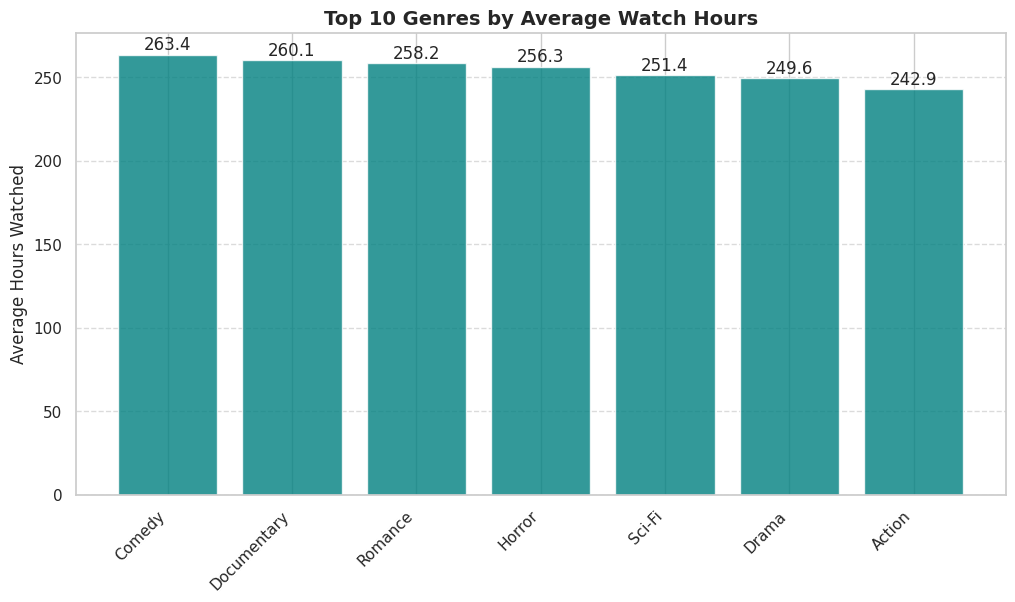

 * The 'Comedy' genre leads the platform in engagement, making it a primary candidate for content investment.

📊 STRATEGIC INSIGHT: USER SEGMENTATION


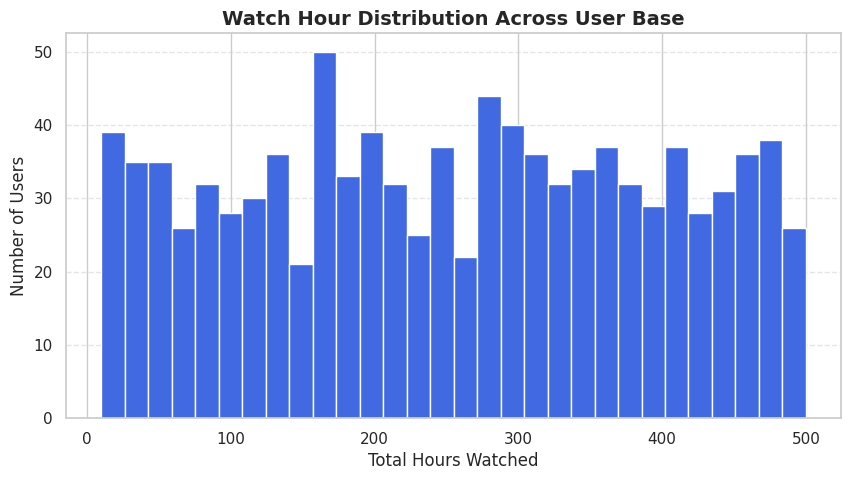

 * Distribution Analysis: The average user watches 254.5 hours. The spread helps identify high-value 'Power Users' vs. 'At-Risk' casual users.

📊 STRATEGIC INSIGHT: GROWTH TRENDS


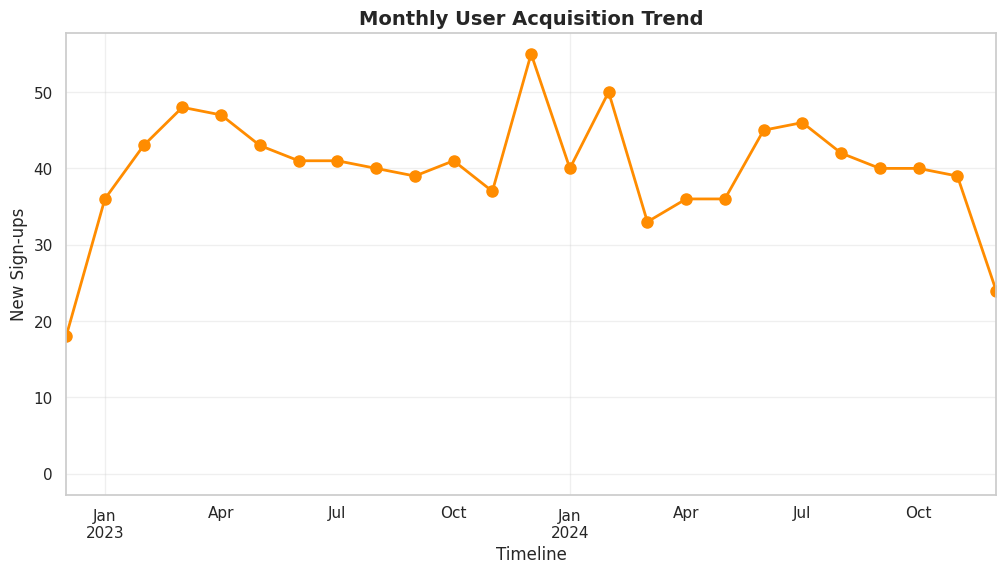

 * Growth Tracking: Platform acquisition peaked in 2023-12. This confirms the steady growth trend identified in the Page 5 report.


In [10]:
import matplotlib.pyplot as plt

# Set a professional style
plt.style.use('seaborn-v0_8-muted')

# --- GENRE PERFORMANCE ANALYSIS ---
#  This aggregates the average watch time for the top 10 genres and presents them in a sorted bar chart.
print("📊 STRATEGIC INSIGHT: CONTENT ENGAGEMENT")
top_genres = df.groupby('Favorite_Genre')['Watch_Hours'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_genres.index, top_genres.values, color='teal', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Genres by Average Watch Hours", fontsize=14, fontweight='bold')
plt.ylabel("Average Hours Watched")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars for immediate readability
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom')

plt.show()
print(f" * The '{top_genres.index[0]}' genre leads the platform in engagement, making it a primary candidate for content investment.")

# --- USER BEHAVIOR DISTRIBUTION ---
# This plots the frequency of watch hours across the entire 1,000-user dataset.
print("\n📊 STRATEGIC INSIGHT: USER SEGMENTATION")
plt.figure(figsize=(10, 5))
plt.hist(df['Watch_Hours'], bins=30, color='royalblue', edgecolor='white')
plt.title("Watch Hour Distribution Across User Base", fontsize=14, fontweight='bold')
plt.xlabel("Total Hours Watched")
plt.ylabel("Number of Users")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

avg_hours = df['Watch_Hours'].mean()
print(f" * Distribution Analysis: The average user watches {avg_hours:.1f} hours. The spread helps identify high-value 'Power Users' vs. 'At-Risk' casual users.")

# --- ACQUISITION VELOCITY ---
# This visualizes the number of new users joining each month.

print("\n📊 STRATEGIC INSIGHT: GROWTH TRENDS")
growth_data = df['Join_Month'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
growth_data.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=8)
plt.fill_between(range(len(growth_data)), growth_data.values, color='orange', alpha=0.1)
plt.title("Monthly User Acquisition Trend", fontsize=14, fontweight='bold')
plt.xlabel("Timeline")
plt.ylabel("New Sign-ups")
plt.grid(True, alpha=0.3)
plt.show()

peak_month = growth_data.idxmax()
print(f" * Growth Tracking: Platform acquisition peaked in {peak_month}. This confirms the steady growth trend identified in the Page 5 report.")